In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

In [13]:
# --- 1. The Multi-Objective Environment ---

class MultiObjectiveGridWorld:
    def __init__(self, size=5):
        self.size = size
        self.agent_pos = [0, 0]
        self.goal_pos = [size - 1, size - 1]
        self.lava_pos = [size - 1, 0]
        self.num_objectives = 2
        self.state_dim = 2 # Agent's (row, col) position
        self.action_dim = 4 # 0: up, 1: down, 2: left, 3: right

    def reset(self):
        self.agent_pos = [0, 0]
        return np.array(self.agent_pos)

    def step(self, action):
        # Move agent
        if action == 0: self.agent_pos[0] = max(0, self.agent_pos[0] - 1)
        elif action == 1: self.agent_pos[0] = min(self.size - 1, self.agent_pos[0] + 1)
        elif action == 2: self.agent_pos[1] = max(0, self.agent_pos[1] - 1)
        elif action == 3: self.agent_pos[1] = min(self.size - 1, self.agent_pos[1] + 1)

        # Get reward vector [r_goal, r_lava]
        reward_vector = np.array([0.0, 0.0])
        done = False

        if self.agent_pos == self.goal_pos:
            reward_vector[0] = 1.0
            done = True
        elif self.agent_pos == self.lava_pos:
            reward_vector[1] = -1.0
            done = True

        return np.array(self.agent_pos), reward_vector, done

    def render(self, ax, path, color, title):
        ax.clear()
        ax.set_title(title)
        grid = np.zeros((self.size, self.size))
        grid[self.goal_pos[0], self.goal_pos[1]] = 1 # Goal
        grid[self.lava_pos[0], self.lava_pos[1]] = -1 # Lava

        ax.imshow(grid, cmap='coolwarm', interpolation='none')

        # Plot path
        path_rows, path_cols = zip(*path)
        ax.plot(path_cols, path_rows, marker='o', color=color, markersize=8, linestyle='-')

        # Mark start
        ax.text(0, 0, 'S', ha='center', va='center', color='white', fontsize=12)
        ax.text(self.goal_pos[1], self.goal_pos[0], 'G', ha='center', va='center', color='black', fontsize=12)
        ax.text(self.lava_pos[1], self.lava_pos[0], 'L', ha='center', va='center', color='black', fontsize=12)

        ax.set_xticks(np.arange(-.5, self.size, 1), minor=True)
        ax.set_yticks(np.arange(-.5, self.size, 1), minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        ax.tick_params(which="minor", size=0)
        ax.set_xticklabels([])
        ax.set_yticklabels([])


In [14]:
# --- 2. The Multi-Objective Q-Network (The "Reward Head") ---

class MO_QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_objectives):
        super(MO_QNetwork, self).__init__()
        self.num_objectives = num_objectives
        self.action_dim = action_dim

        self.layers = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            # The head outputs a value for each objective for each action
            nn.Linear(128, action_dim * num_objectives)
        )

    def forward(self, state):
        raw_output = self.layers(state)
        # Reshape to (batch_size, num_actions, num_objectives)
        # This makes it easier to work with the Q-vectors for each action
        return raw_output.view(-1, self.action_dim, self.num_objectives)


In [15]:
# --- 3. The MORL Agent ---

class MORLAgent:
    def __init__(self, env, gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995, lr=1e-4, batch_size=64):
        self.env = env
        self.state_dim = env.state_dim
        self.action_dim = env.action_dim
        self.num_objectives = env.num_objectives

        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.policy_net = MO_QNetwork(self.state_dim, self.action_dim, self.num_objectives).to(self.device)
        self.target_net = MO_QNetwork(self.state_dim, self.action_dim, self.num_objectives).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.replay_buffer = deque(maxlen=10000)

    def select_action(self, state, preference_weights):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)

        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            # Get Q-vectors for all actions: shape (1, num_actions, num_objectives)
            q_vectors = self.policy_net(state_tensor)

            # Scalarize using the preference weights
            # (1, num_actions, num_objectives) @ (num_objectives, 1) -> (1, num_actions, 1)
            scalarized_q_values = torch.matmul(q_vectors, preference_weights.unsqueeze(1))

            # Choose action with the highest scalarized Q-value
            return scalarized_q_values.argmax().item()

    def store_transition(self, state, action, reward_vector, next_state, done):
        self.replay_buffer.append((state, action, reward_vector, next_state, done))

    def optimize_model(self, preference_weights):
        if len(self.replay_buffer) < self.batch_size:
            return

        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, reward_vectors, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        # Convert list of numpy arrays to single numpy array before converting to tensor
        reward_vectors = torch.FloatTensor(np.array(reward_vectors)).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.BoolTensor(dones).to(self.device)

        # Get the Q-vectors for the actions that were actually taken
        # We use gather to select the Q-vector for the specific action taken
        q_vectors_current = self.policy_net(states).gather(1, actions.unsqueeze(1).unsqueeze(2).expand(-1, 1, self.num_objectives)).squeeze(1)

        with torch.no_grad():
            # Get Q-vectors for all next actions from the target network
            next_q_vectors = self.target_net(next_states) # shape: (batch_size, num_actions, num_objectives)

            # Scalarize the next Q-vectors to find the best next action for each state in the batch
            scalarized_next_q = torch.matmul(next_q_vectors, preference_weights.unsqueeze(1)).squeeze(2)

            # Find the index (action) of the max scalarized value
            best_next_actions = scalarized_next_q.argmax(dim=1)

            # Use this index to get the corresponding full Q-vector
            best_next_q_vectors = next_q_vectors.gather(1, best_next_actions.unsqueeze(1).unsqueeze(2).expand(-1, 1, self.num_objectives)).squeeze(1)

            # If an episode was done, the future reward is 0
            best_next_q_vectors[dones] = 0.0

            # The Bellman update is now on vectors
            target_q_vectors = reward_vectors + self.gamma * best_next_q_vectors

        # Loss is calculated between the predicted and target VECTORS
        loss = nn.MSELoss()(q_vectors_current, target_q_vectors)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Epsilon decay
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def update_target_net(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

In [16]:
# --- 4. Training and Evaluation ---

def train(agent, preference_weights, episodes=200):
    print(f"--- Training with weights {preference_weights} ---")
    preference_weights_tensor = torch.FloatTensor(preference_weights).to(agent.device)
    for episode in range(episodes):
        state = agent.env.reset()
        done = False
        while not done:
            action = agent.select_action(state, preference_weights_tensor)
            next_state, reward_vector, done = agent.env.step(action)
            agent.store_transition(state, action, reward_vector, next_state, done)
            agent.optimize_model(preference_weights_tensor)
            state = next_state

        if episode % 10 == 0:
            agent.update_target_net()

        if episode % 10 == 0:
            print(f"Episode {episode}/{episodes}")

def evaluate(agent, preference_weights):
    path = []
    state = agent.env.reset()
    path.append(list(state))
    done = False
    agent.epsilon = 0 # Greedy evaluation
    preference_weights_tensor = torch.FloatTensor(preference_weights).to(agent.device)

    steps = 0
    while not done and steps < 20: # Add step limit to avoid infinite loops
        action = agent.select_action(state, preference_weights_tensor)
        state, _, done = agent.env.step(action)
        path.append(list(state))
        steps += 1
    return path

In [17]:
env = MultiObjectiveGridWorld(size=5)


In [7]:
# Agent 1: "Greedy" - cares much more about the goal
weights_greedy = np.array([0.9, 0.1])
agent_greedy = MORLAgent(env)
train(agent_greedy, weights_greedy)
path_greedy = evaluate(agent_greedy, weights_greedy)


--- Training with weights [0.9 0.1] ---
Episode 0/100
Episode 10/100
Episode 20/100
Episode 30/100
Episode 40/100
Episode 50/100
Episode 60/100
Episode 70/100
Episode 80/100
Episode 90/100


In [ ]:
# Agent 2: "Cautious" - cares much more about avoiding lava
weights_cautious = np.array([0.1, 0.9])
agent_cautious = MORLAgent(env)
train(agent_cautious, weights_cautious)
path_cautious = evaluate(agent_cautious, weights_cautious)


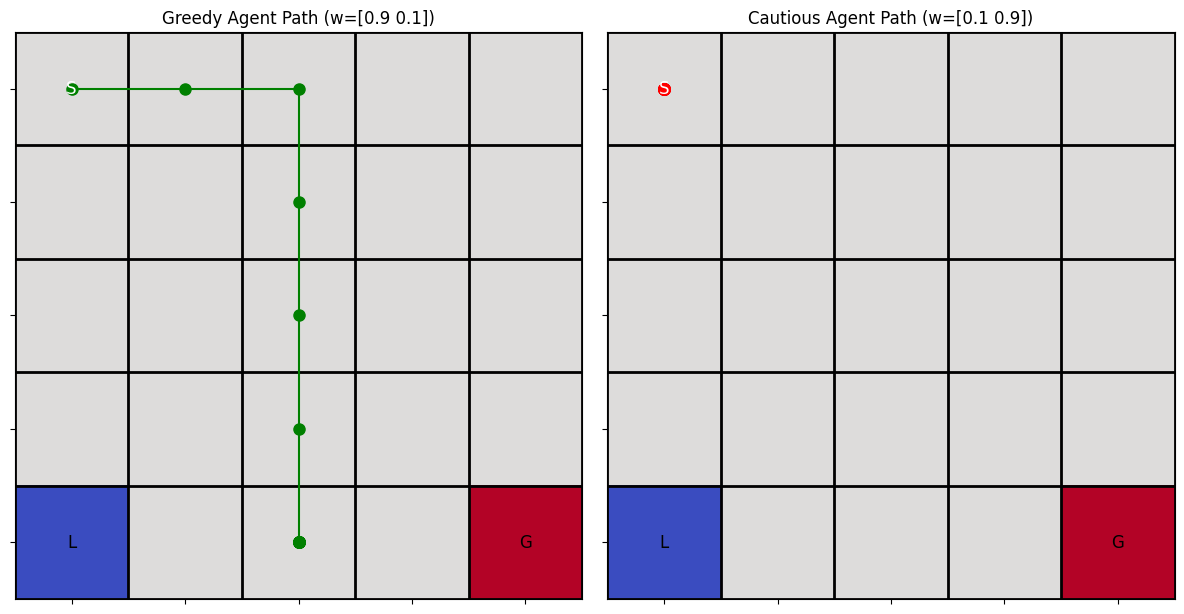

In [11]:
# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

env.render(ax1, path_greedy, 'green', f'Greedy Agent Path (w={weights_greedy})')
env.render(ax2, path_cautious, 'red', f'Cautious Agent Path (w={weights_cautious})')

plt.tight_layout()
plt.show()

In [ ]:



# Agent 2: "Cautious" - cares much more about avoiding lava
weights_cautious = np.array([0.1, 0.9])
agent_cautious = MORLAgent(env)
train(agent_cautious, weights_cautious)
path_cautious = evaluate(agent_cautious, weights_cautious)

# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

env.render(ax1, path_greedy, 'green', f'Greedy Agent Path (w={weights_greedy})')
env.render(ax2, path_cautious, 'red', f'Cautious Agent Path (w={weights_cautious})')

plt.tight_layout()
plt.show()